# Preprocessing: clustering demo

Notebook này minh hoạ một quy trình phân nhóm (clustering) các chuỗi thời gian nhằm phục vụ việc lựa chọn mô hình và chiến lược huấn luyện (local vs global, deterministic vs probabilistic).

Ý tưởng chính là **biểu diễn mỗi chuỗi thời gian bằng một vector feature**, sau đó phân cụm trong không gian feature để nhóm các series có đặc tính tương đồng. Cách tiếp cận “feature-based time-series analysis” đã được chứng minh hiệu quả trong phân tích tổng quát, trực quan hoá instance space và hỗ trợ lựa chọn mô hình dự báo [1][2][3].


## Mục tiêu chính

**Nhóm các series có đặc tính giống nhau để có thể fit chung một mô hình hiệu quả và có ý nghĩa.**

Các cluster được dùng để:

* Quyết định local vs global model
* Gợi ý model family phù hợp (structural vs probabilistic vs robust)
* Giải thích vì sao các series nên / không nên fit chung

Cách tiếp cận này phù hợp với hướng “meta-learning for forecasting”, trong đó features của chuỗi thời gian được dùng để mô tả đặc tính và dự đoán hành vi thuật toán [2][3]


# 1. Feature Bank Extraction

Mỗi chuỗi thời gian được biểu diễn bằng một **feature bank** mô tả các khía cạnh khác nhau của dữ liệu. Feature bank không chỉ phục vụ clustering mà còn phục vụ “diagnosis” để chỉ ra vì sao series khó (hard) và cần xử lý khác nhau.

Tư duy feature-based này tương đồng với các framework tổng quan như hctsa [4] và feature-based instance space trong forecasting [5], trong đó chuỗi thời gian được ánh xạ sang vector feature để phân tích phân nhóm và tìm feature có khả năng phân biệt.

### (a) Data quality / validity

**missing_ratio, constant_ratio, n_obs**

* Mục tiêu: phát hiện chuỗi thiếu dữ liệu, không đủ quan sát hoặc gần như không biến động.
* Hành động: cảnh báo/loại trừ sớm hoặc xử lý đặc thù trước khi fit model.

Các feature nhóm này chủ yếu đóng vai trò gating/validity check, tránh việc clustering bị nhiễu bởi series “không đủ tín hiệu”.


### (b) Distribution / demand pattern (chỉ áp dụng khi zero-value có ý nghĩa)

**zero_ratio, ADI, CV², demand_type**

Nhóm feature này nhằm mô tả intermittent / zero-inflated demand, vốn thường không có structure theo nghĩa trend/seasonality. Taxonomy dựa trên ADI và CV² là một cách phân loại chuẩn trong intermittent demand forecasting [6], và được sử dụng rộng rãi để định hướng lựa chọn mô hình phù hợp [7].

* ADI (Average Demand Interval) đo mức độ gián đoạn giữa các lần demand > 0
* CV² đo mức độ biến thiên của positive demand


### (c) Structural / temporal shape

**trend_strength, seasonality_strength, acf1, acf_seasonal**

Nhóm feature này mô tả “độ mạnh cấu trúc” của chuỗi thời gian, đóng vai trò nền tảng để định nghĩa similarity giữa các series trong clustering.

* Strength of trend/seasonality được định nghĩa từ STL decomposition theo variance ratio [8].
* ACF lag 1 và seasonal lag phản ánh mức độ persistence và seasonal correlation.

Nhóm feature này đóng vai trò trọng tâm vì nó liên quan trực tiếp đến việc series có thể “chia sẻ mô hình” hay không.


### (d) Drift / regime change

**stability, lumpiness**

Nhóm feature này nhằm phát hiện nonstationarity/regime change theo thời gian.
Trong thực hành forecasting, các series có thay đổi chế độ thường yêu cầu rolling training, adaptation hoặc segmentation. Cơ sở lý thuyết của việc quan tâm đến structural break/regime change được tổng hợp trong review về change point detection [10].


### (e) Event / shock

**spike_strength, anomaly_ratio**

Nhóm feature này nhằm phát hiện series bị chi phối bởi event, shock hoặc outlier.
Các hiện tượng anomaly/spike trong time series là một chủ đề lớn và có thể làm sai lệch việc huấn luyện nếu không xử lý robust [11].


Hai nhóm feature về regime change và shock cũng đóng vai trò quan trọng trong phương pháp chỉ ra các chuỗi thời gian bất thường trong một tập chuỗi lớn [9] 


### (f) Complexity / intrinsic predictability

**spectral_entropy, WPE**

Nhóm feature này đo mức độ “intrinsic unpredictability” của chuỗi, nhằm cảnh báo các series không nên kỳ vọng accuracy cao do cấu trúc nội tại yếu hoặc quá phức tạp.

* Weighted Permutation Entropy (WPE) là thước đo complexity có xét biên độ, hữu ích để đánh giá độ ngẫu nhiên/khó dự báo [12][13] Các thước đo entropy được tổng hợp trong survey của Mihailović gần đây và nhấn mạnh vai trò trong đo lường complexity/predictability của time series [14].


## Mapping feature → hard type → action (decision-ready)

| Hard type                       | Câu hỏi chính                 | Feature                       | Hành động                                          |
| ------------------------------- | ----------------------------- | ----------------------------- | -------------------------------------------------- |
| Distribution-dominated (Type C) | Zero/intermittent demand?     | ADI, CV², zero_ratio          | Probabilistic / intermittent methods               |
| Intrinsic unpredictability      | Có structure đủ mạnh không?   | spectral_entropy, WPE         | Cảnh báo low predictability, ceiling accuracy thấp |
| Drift / regime change           | Có đổi chế độ theo thời gian? | stability, lumpiness          | Rolling / adaptive / segmentation                  |
| Event / spike                   | Có shock/outlier dominance?   | spike_strength, anomaly_ratio | Robust training + outlier handling                 |


# 2. (Optional) Detect Distribution-Dominated Series (Type C)

Trước khi clustering theo structure, notebook tách riêng Type C - các series mà hành vi chủ yếu bị chi phối bởi phân bố (intermittent, zero-inflated demand). Việc dùng ADI và CV² để phân loại demand pattern có nền tảng trong intermittent demand forecasting [6][7].

**Lý do tách sớm**

* Type C thường có trend/season/ACF yếu → clustering theo shape/structure ít ý nghĩa
* Tối ưu hơn nếu route thẳng sang nhóm mô hình probabilistic / intermittent (Croston family, SBA variants)

Trong demo:

* Type C được phát hiện bằng ADI + CV² (tham khảo thêm threshold theo Janssen, thesis [15])
* Các bước PCA & clustering chỉ áp dụng cho **non-C**
* Type C được profile theo demand type (intermittent vs lumpy)


# 3. PCA for Insight & Feature Selection

PCA được dùng nhằm:

* Giảm tương quan giữa feature
* Hiểu feature nào thực sự phân hoá dữ liệu
* Tránh clustering bị chi phối bởi noise / heavy tail


**Quy trình**

* Log-transform các feature heavy-tailed (spike, anomaly, lumpiness…)
* Standardize
* Fit PCA trên non-C
* Chọn số PC giải thích ~80–90% variance
* Phân tích loadings/squared loadings để chọn subset feature phù hợp cho similarity clustering

**Lưu ý về skew/kurtosis**
Một số feature distributional như skewness/kurtosis có thể không được đưa trực tiếp vào similarity clustering mà dùng như:

* kiểm tra heavy tail / outlier dominance
* quyết định log-transform hoặc robust scaling
  (đây là bước tiền xử lý để tránh feature heavy-tailed chi phối PCA/KMeans).


# 4. Clustering Strategy

Notebook thử hai chiến lược:

### (a) Clustering trên PCA embeddings

Phù hợp khi:

* nhiều feature
* cần giảm chiều mạnh

Ưu điểm: compact, orthogonal
Nhược điểm: dễ bị dominant PC chi phối nếu PC đó không đúng “similarity semantics”.

### (b) Clustering trực tiếp trên subset feature (recommended trong demo)

Nếu PCA cho thấy:

* chỉ 1–2 trục chính mang ý nghĩa similarity (structure vs entropy)
* các PC còn lại chủ yếu là noise/diagnosis, notebook cluster trực tiếp trên subset feature đó (đã scale).


## Chọn số cụm (k)

Silhouette thường bias về k nhỏ (đặc biệt k=2), nên notebook dùng composite score kết hợp:

* Silhouette (separation)
* Within-cluster dispersion (homogeneity)
* Size imbalance (tránh fragmentation)

Mục tiêu: chọn k nhỏ nhất nhưng cải thiện rõ rệt độ đồng nhất trong cluster, phù hợp với yêu cầu routing (không tạo quá nhiều nhánh model).


# 5. (Optional) DTW refinement inside a small structured cluster

Ngoài Feature-based clustering là phương pháp chính ta dùng để hỗ trợ bước modeling, shape-based clustering cũng được sử dụng rộng rãi [16]. Trong một số cluster có structure mạnh nhưng bị chi phối bởi event/regime timing khác nhau, notebook thử thêm bước refinement theo **DTW**.

DTW (Dynamic Time Warping) là một distance measure phổ biến trong shape-based clustering, cho phép so sánh chuỗi khi có lệch pha hoặc lệch thời điểm [17]. Bước này được dùng cục bộ trên cluster nhỏ nhằm:

* kiểm tra giả thuyết cluster đang chứa nhiều regime timing
* tách nhóm “early-onset vs late-onset” (theo thực nghiệm demo)

Do chi phí cao và kém ổn định trên các nhóm series heterogeneous hoặc weakly structured, ta chỉ dùng DTW như “regime flag” trên cụm đã có đặc tính chung, không thay thế feature clustering.

# 6. Thử nghiệm 1 số phương pháp khác:
- **Feature extraction:** sử dụng package tsfeatures, MSTL thay vì STL.
- **Giảm chiều:** UMAP thay cho PCA
- **Clustering:** GMM thay cho Kmeans hoặc thay cho DTW ở layer-2.


**References**

[1] https://arxiv.org/pdf/1709.08055

[2] https://www.sciencedirect.com/science/article/abs/pii/S0169207016301030

[3] https://www.robjhyndman.com/papers/fforms.pdf

[4] https://github.com/benfulcher/hctsa

[5] https://github.com/Nixtla/tsfeatures

[6] https://doi.org/10.1016/j.ijforecast.2004.10.001

[7] https://doi.org/10.1007/s12046-020-1285-8

[8] https://otexts.com/fpp2/seasonal-strength.html

[9] https://robjhyndman.com/papers/icdm2015.pdf

[10] https://arxiv.org/pdf/1801.00718

[11] https://arxiv.org/pdf/2002.04236

[12] https://doi.org/10.1103/physreve.87.022911

[13] https://pubmed.ncbi.nlm.nih.gov/25493861/

[14] https://pubmed.ncbi.nlm.nih.gov/40566185/

[15] https://pure.tue.nl/ws/portalfiles/portal/230369575/Master_Thesis_Iris_Janssen.pdf

[16] https://www.sciencedirect.com/science/article/abs/pii/S0306437915000733

[17] https://rstudio-pubs-static.s3.amazonaws.com/474160_0761428e8683401e941a92a4177254a4.html

## Import & Load data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy, skew, kurtosis
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
import ordpy
import antropy as ant

In [32]:
from statsmodels.tsa.seasonal import MSTL

In [33]:
pd.set_option("display.max_columns", 20)

RANDOM_STATE = 42
SEASONAL_PERIOD = 7

In [34]:
data_path = "m5_preprocess_data.csv"
df = pd.read_csv(data_path, parse_dates=["date"])
df = df.set_index("date").sort_index()
df.head()

,FOODS_1_001,FOODS_1_002,FOODS_1_003,FOODS_1_004,FOODS_1_005,FOODS_1_006,FOODS_1_008,FOODS_1_009,FOODS_1_010,FOODS_1_011,...,HOUSEHOLD_2_507,HOUSEHOLD_2_508,HOUSEHOLD_2_509,HOUSEHOLD_2_510,HOUSEHOLD_2_511,HOUSEHOLD_2_512,HOUSEHOLD_2_513,HOUSEHOLD_2_514,HOUSEHOLD_2_515,HOUSEHOLD_2_516
date,,,,,,,,,,,,,,,,,,,,,
2013-08-27,0,0,1,4,1,3,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
2013-08-28,0,0,1,8,2,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
2013-08-29,0,0,0,11,3,0,0,4,0,3,...,1,0,0,2,0,0,1,0,0,0
2013-08-30,1,0,1,16,3,4,0,1,0,3,...,1,0,0,0,0,0,0,0,0,0
2013-08-31,0,0,2,10,3,3,0,0,0,0,...,1,1,2,3,0,4,0,0,0,0


## Note:

The data used in this demo already satisfies minimal time-series validity requirements: valid timestamps, consistent frequency, no missing observations, and all series contain valid numeric values. Some series contain a high proportion of zero values (up to ~98%). These are treated as valid observations (no sales on a given day), not missing data. As most of the series are zero-heavy, we avoid using outlier clipping and compute features directly on the raw series.

## 1. Feature Extraction

In [35]:
def _prepare_1d_array(x: pd.Series, *, tie_precision: int | None = None, jitter: float = 0.0):
    """Return clean 1D np.array for entropy computation."""
    a = x.astype(float).to_numpy()
    a = a[np.isfinite(a)]
    if a.size == 0:
        return a

    # Optional: rounding to reduce tiny float noise and allow tie handling
    if tie_precision is not None:
        a = np.round(a, tie_precision)

    # Optional: tiny jitter to break exact ties (use cautiously; keep tiny)
    if jitter > 0:
        rng = np.random.default_rng(0)
        a = a + rng.normal(0.0, jitter, size=a.shape)

    return a

In [51]:
def _stl_components(series: pd.Series, seasonal_period: int):
    """Seasonal period fixed by frequency for scalable feature extraction; refined later"""
    stl = STL(series, period=seasonal_period, robust=True)
    res = stl.fit()
    return res.trend, res.seasonal, res.resid


def _strength(component: np.ndarray, resid: np.ndarray):
    """For computing trend & seasonal strength"""
    var_resid = np.nanvar(resid)
    var_total = np.nanvar(component + resid)
    if var_total <= 0:
        return 0.0
    return max(0.0, 1 - var_resid / var_total)


def _spectral_entropy(series: pd.Series):
    x = series.values
    if len(x) == 0:
        return np.nan
    x = x - np.nanmean(x)
    spectrum = np.fft.rfft(x)
    psd = np.abs(spectrum) ** 2
    psd_sum = psd.sum()
    if psd_sum == 0:
        return np.nan
    psd /= psd_sum
    se = entropy(psd, base=2)
    max_entropy = np.log2(len(psd)) if len(psd) > 0 else 1
    return se / max_entropy


def _stability_lumpiness(series: pd.Series, width: int):
    windows = [series[i : i + width] for i in range(0, len(series), width)]
    window_means = [w.mean() for w in windows if len(w) == width]
    window_vars = [w.var() for w in windows if len(w) == width]
    stability = np.var(window_means) if window_means else np.nan
    lumpiness = np.var(window_vars) if window_vars else np.nan
    return stability, lumpiness


def _adi_cv2(series: pd.Series):
    events = series > 0
    zero_ratio = 1 - events.mean()
    event_idx = np.flatnonzero(events.values)
    if len(event_idx) > 1:
        adi = np.diff(event_idx).mean()
    else:
        adi = np.inf
    positive = series[series > 0]
    if len(positive) > 1 and positive.mean() > 0:
        cv2 = (positive.std() / positive.mean()) ** 2
    else:
        cv2 = np.inf
    return zero_ratio, adi, cv2


def _acf_at_lag(series: pd.Series, lag: int):
    """Support function to compute acf"""
    x = series.values
    if len(x) <= lag:
        return np.nan
    try:
        acf_vals = acf(x, nlags=lag, fft=True, missing="drop")
        return acf_vals[lag]
    except Exception:
        return np.nan


def _acf_features(series: pd.Series, seasonal_period: int):
    acf1 = _acf_at_lag(series, lag=1)
    acf_seasonal = (
        _acf_at_lag(series, lag=seasonal_period)
        if seasonal_period is not None and seasonal_period > 1
        else np.nan
    )
    return acf1, acf_seasonal


def _spike_strength(resid: np.ndarray, q: float = 0.99):
    """
    Measure spike / shock dominance in residual component.
    High value: rare but strong shocks.
    Low value: smooth residuals.
    """
    resid = resid[np.isfinite(resid)]
    if resid.size < 10:
        return np.nan

    eps = 1e-8
    mad = stats.median_abs_deviation(resid, nan_policy="omit")
    mad = mad if mad > 0 else np.nanmedian(np.abs(resid)) + eps

    spike = np.nanpercentile(np.abs(resid), q * 100) / (mad + eps)
    return float(spike)


def _anomaly_ratio(resid: np.ndarray, z: float = 5.0):
    """Fraction of points that are extreme anomalies in residual"""
    resid = resid[np.isfinite(resid)]
    if resid.size < 10:
        return np.nan

    mad = stats.median_abs_deviation(resid, nan_policy="omit")
    if mad <= 0:
        return 0.0

    zscore = np.abs(resid) / mad
    return float(np.mean(zscore > z))


def _wpe_feature(series: pd.Series,*,dx: int = 5,tau: int = 1,tie_precision: int | None = 0,jitter: float = 0.0):
    """Weighted Permutation Entropy (normalized to [0,1]): intrinsic predictability"""
    a = _prepare_1d_array(series, tie_precision=tie_precision, jitter=jitter)
    if a.size < 50:
        return np.nan

    wpe = ordpy.weighted_permutation_entropy(
        a,
        dx=dx,
        dy=1,
        taux=tau,
        tauy=1,
        base=2,
        normalized=True,
        tie_precision=None,
    )
    return float(wpe)

In [52]:
def compute_features(df_metrics: pd.DataFrame, seasonal_period: int = SEASONAL_PERIOD):
    records = []
    for col in df_metrics.columns:
        series = df_metrics[col].astype(float)
        if series.isna().all():
            continue
        try:
            trend, seasonal, resid = _stl_components(series, seasonal_period)
        except Exception:
            trend = pd.Series(np.zeros_like(series), index=series.index)
            seasonal = pd.Series(np.zeros_like(series), index=series.index)
            resid = series - series.mean()

        trend_strength = _strength(trend.values, resid.values)
        seasonality_strength = _strength(seasonal.values, resid.values)
        spectral_entropy = _spectral_entropy(series)
        stability, lumpiness = _stability_lumpiness(series, width=seasonal_period)
        zero_ratio, adi, cv2 = _adi_cv2(series)
        acf1, acf_seasonal = _acf_features(series, seasonal_period)
        spike_strength = _spike_strength(resid.values)
        anomaly_ratio = _anomaly_ratio(resid.values)
        wpe = _wpe_feature(series)

        records.append(
            {
                "series_id": col,

                # Data quality
                "missing_ratio": series.isna().mean(),
                "constant_ratio": (series.diff().abs().fillna(0) == 0).mean(),

                # Structure
                "trend_strength": trend_strength,
                "seasonality_strength": seasonality_strength,
                "acf1": acf1,
                "acf_seasonal": acf_seasonal,

                # Complexity
                "spectral_entropy": spectral_entropy,
                "wpe": wpe,

                # Drift / regime
                "stability": stability,     # mean-instability
                "lumpiness": lumpiness,     # variance-instability

                # Event / shock
                "spike_strength": spike_strength,
                "anomaly_ratio": anomaly_ratio,

                # Distribution
                "zero_ratio": zero_ratio,
                "adi": adi,
                "cv2": cv2,
            }
        )
    features_df = pd.DataFrame.from_records(records).set_index("series_id")
    return features_df


features_df = compute_features(df)
features_df.head()

,missing_ratio,constant_ratio,trend_strength,seasonality_strength,acf1,acf_seasonal,spectral_entropy,wpe,stability,lumpiness,spike_strength,anomaly_ratio,zero_ratio,adi,cv2
series_id,,,,,,,,,,,,,,,
FOODS_1_001,0.0,0.458,0.037649,0.016085,0.015773,0.016493,0.923285,0.800211,0.213746,1.329443,73.365307,0.341,0.615,2.585938,0.395943
FOODS_1_002,0.0,0.596,0.063236,0.033057,0.060288,0.051445,0.923004,0.731577,0.091037,0.220008,377.705334,0.340,0.723,2.927536,0.217531
FOODS_1_003,0.0,0.401,0.027775,0.105413,0.020850,0.008816,0.932705,0.796891,0.155970,2.135279,15.815924,0.147,0.569,2.323256,0.405212
FOODS_1_004,0.0,0.196,0.569705,0.166487,0.651967,0.436041,0.720678,0.905950,40.763212,2882.143244,17.777316,0.157,0.155,1.183649,0.441693
FOODS_1_005,0.0,0.463,0.209649,0.120612,0.210544,0.177072,0.896675,0.835349,0.838905,49.829205,124.109817,0.377,0.542,2.185996,0.873878


## 2. Detect Distribution-dominant

In [53]:
def classify_demand_adi_cv2(
    features_df: pd.DataFrame,
    adi_col: str = "adi",
    cv2_col: str = "cv2",
    adi_thresh: float = 1.32,
    cv2_thresh: float = 0.49,
):
    df = features_df.copy()

    conditions = [
        (df[adi_col] <= adi_thresh) & (df[cv2_col] <= cv2_thresh),
        (df[adi_col] <= adi_thresh) & (df[cv2_col] > cv2_thresh),
        (df[adi_col] > adi_thresh) & (df[cv2_col] <= cv2_thresh),
        (df[adi_col] > adi_thresh) & (df[cv2_col] > cv2_thresh),
    ]

    choices = ["smooth", "erratic", "intermittent", "lumpy"]

    df["demand_type"] = np.select(conditions, choices, default="unknown")

    return df[["demand_type"]]

In [54]:
demand_type_df = classify_demand_adi_cv2(features_df)

demand_type_df["demand_type"].value_counts()

demand_type
intermittent    2222
lumpy            471
smooth           275
erratic           81
Name: count, dtype: int64

In [55]:
demand_type_df["is_C"] = demand_type_df["demand_type"].isin(
    ["intermittent", "lumpy"]
)

In [56]:
distribution_df = features_df.join(demand_type_df)
distribution_df

,missing_ratio,constant_ratio,trend_strength,seasonality_strength,acf1,acf_seasonal,spectral_entropy,wpe,stability,lumpiness,spike_strength,anomaly_ratio,zero_ratio,adi,cv2,demand_type,is_C
series_id,,,,,,,,,,,,,,,,,
FOODS_1_001,0.0,0.458,0.037649,0.016085,0.015773,0.016493,0.923285,0.800211,0.213746,1.329443,73.365307,0.341,0.615,2.585938,0.395943,intermittent,True
FOODS_1_002,0.0,0.596,0.063236,0.033057,0.060288,0.051445,0.923004,0.731577,0.091037,0.220008,377.705334,0.340,0.723,2.927536,0.217531,intermittent,True
FOODS_1_003,0.0,0.401,0.027775,0.105413,0.020850,0.008816,0.932705,0.796891,0.155970,2.135279,15.815924,0.147,0.569,2.323256,0.405212,intermittent,True
FOODS_1_004,0.0,0.196,0.569705,0.166487,0.651967,0.436041,0.720678,0.905950,40.763212,2882.143244,17.777316,0.157,0.155,1.183649,0.441693,smooth,False
FOODS_1_005,0.0,0.463,0.209649,0.120612,0.210544,0.177072,0.896675,0.835349,0.838905,49.829205,124.109817,0.377,0.542,2.185996,0.873878,lumpy,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HOUSEHOLD_2_512,0.0,0.444,0.036336,0.078417,-0.003845,0.045229,0.932863,0.766031,0.174574,4.000913,25.074339,0.184,0.618,2.606299,0.539731,lumpy,True
HOUSEHOLD_2_513,0.0,0.441,0.234135,0.137828,0.274830,0.259201,0.849645,0.875772,0.535624,2.988780,29.666083,0.210,0.526,2.107822,0.439503,intermittent,True
HOUSEHOLD_2_514,0.0,0.637,0.000000,0.046349,0.028107,-0.001038,0.925613,0.622167,0.030825,0.044351,481.074328,0.313,0.769,4.230435,0.088074,intermittent,True


## 3. Feature hygiene & validation

In [57]:
# Features used for PCA 
PCA_FEATURES = [
    # Structure
    "trend_strength",
    "seasonality_strength",
    "acf1",
    "acf_seasonal",

    # Drift / regime
    "stability",
    "lumpiness",

    # Event / shock
    "spike_strength",
    "anomaly_ratio",

    # Complexity
    "spectral_entropy",
    "wpe",
]

In [58]:
# Only non-C series
nonC_df = distribution_df.loc[~distribution_df["is_C"]]

X_nonC = nonC_df[PCA_FEATURES].copy()
X_nonC = X_nonC.dropna(how="any")

### Detect heavy-tailed feature to avoid outliers after scaling

In [18]:
def heavy_tail_diagnostics(df: pd.DataFrame):
    records = []
    for col in df.columns:
        x = df[col].dropna()
        if len(x) < 10:
            continue

        rec = {
            "feature": col,
            "mean": x.mean(),
            "std": x.std(),
            "skewness": skew(x),
            "kurtosis": kurtosis(x, fisher=False),  # >3 = heavy tail
            "p50": x.quantile(0.50),
            "p75": x.quantile(0.75),
            "p90": x.quantile(0.90),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
        }

        rec["p99_p50_ratio"] = (
            rec["p99"] / rec["p50"] if rec["p50"] > 0 else np.inf
        )
        rec["p99_p75_ratio"] = (
            rec["p99"] / rec["p75"] if rec["p75"] > 0 else np.inf
        )
        rec["iqr"] = rec["p75"] - rec["p50"]

        records.append(rec)

    return pd.DataFrame(records).set_index("feature")

ht_stats = heavy_tail_diagnostics(X_nonC)

In [19]:
def flag_heavy_tailed(
    stats_df: pd.DataFrame,
    skew_th=2.0,
    kurt_th=10.0,
    p99_p50_th=10.0,
):
    flags = []
    for _, r in stats_df.iterrows():
        is_heavy = (
            (abs(r["skewness"]) >= skew_th)
            or (r["kurtosis"] >= kurt_th)
            or (r["p99_p50_ratio"] >= p99_p50_th)
        )
        flags.append(is_heavy)
    out = stats_df.copy()
    out["heavy_tailed"] = flags
    return out

ht_flagged = flag_heavy_tailed(ht_stats)
ht_flagged[ht_flagged["heavy_tailed"] == True]

,mean,std,skewness,kurtosis,p50,p75,p90,p95,p99,p99_p50_ratio,p99_p75_ratio,iqr,heavy_tailed
feature,,,,,,,,,,,,,
seasonality_strength,2.402297e-01,1.150294e-01,2.415598,14.869212,0.226022,0.289301,0.356943,0.406765,6.329373e-01,2.800330e+00,2.187813e+00,0.063279,True
stability,1.620441e+01,1.078316e+02,16.968666,306.147080,2.806493,7.823631,21.338323,57.410456,1.517246e+02,5.406200e+01,1.939312e+01,5.017138,True
lumpiness,3.068557e+04,5.382821e+05,18.774089,353.642482,49.671364,367.341023,3725.234379,9335.862577,4.179392e+04,8.414087e+02,1.137742e+02,317.669659,True
spike_strength,8.877995e+06,1.157205e+08,16.584411,293.116750,11.226580,14.844772,20.669390,42.869148,7.620529e+07,6.787935e+06,5.133477e+06,3.618192,True
anomaly_ratio,1.204579e-01,8.268635e-02,2.828690,11.383095,0.098000,0.132250,0.182000,0.362500,4.900000e-01,5.000000e+00,3.705104e+00,0.034250,True


In [59]:
# log-transform heavy-tailed features 
for col in ["spike_strength", "anomaly_ratio", "seasonality_strength", "stability", "lumpiness"]:
    if col in X_nonC.columns:
        X_nonC[col] = np.log1p(X_nonC[col])

In [83]:
def clip_outliers(df, q_low=0.01, q_high=0.99):
    df_clipped = df.copy()
    for col in df.columns:
        lo, hi = df[col].quantile([q_low, q_high])
        df_clipped[col] = df[col].clip(lo, hi)
    return df_clipped

X_nonC = clip_outliers(X_nonC)

### Remove near-constant feature

In [85]:
from sklearn.feature_selection import VarianceThreshold

def remove_near_constant(df, threshold=1e-4, verbose=True):
    vt = VarianceThreshold(threshold=threshold)
    X_new = vt.fit_transform(df)

    kept_mask = vt.get_support()
    kept_cols = df.columns[kept_mask]
    dropped_cols = df.columns[~kept_mask]

    if verbose:
        if len(dropped_cols) == 0:
            print("No near-constant features dropped.")
        else:
            variances = df.var()
            for c in dropped_cols:
                print(f"DROPPED: {c:25s} | variance = {variances[c]:.3e}")

    return (
        pd.DataFrame(X_new, columns=kept_cols, index=df.index),
        dropped_cols.tolist()
    )

X_nonC_vt, dropped_vt = remove_near_constant(X_nonC)

No near-constant features dropped.


### Drop highly correlated features

In [143]:
def correlation_filter_verbose(
    df,
    th=0.9,
    prefer="higher_variance",  # or "first", "second"
    verbose=True
):
    corr = df.corr().abs()
    variances = df.var()

    dropped = set()
    reports = []

    cols = df.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]
            if corr.loc[c1, c2] > th:
                # decide which to drop
                if prefer == "higher_variance":
                    drop = c2 if variances[c1] >= variances[c2] else c1
                elif prefer == "first":
                    drop = c2
                elif prefer == "second":
                    drop = c1

                dropped.add(drop)
                reports.append(
                    (c1, c2, corr.loc[c1, c2], drop)
                )

    if verbose:
        if not reports:
            print("No highly correlated feature pairs found.")
        else:
            for c1, c2, r, d in reports:
                print(
                    f"{c1:22s} vs {c2:22s} | corr = {r:.3f} | drop: {d}"
                )

    kept_cols = [c for c in df.columns if c not in dropped]
    return df[kept_cols], list(dropped)

X_nonC_corr, dropped_corr = correlation_filter_verbose(
    X_nonC_vt,
    th=0.9,
    prefer="higher_variance"
)

trend_strength         vs acf1                   | corr = 0.949 | drop: trend_strength
acf_seasonal           vs spectral_entropy       | corr = 0.946 | drop: spectral_entropy
stability              vs lumpiness              | corr = 0.904 | drop: stability


In [144]:
scaler = StandardScaler()
X_nonC_scaled = scaler.fit_transform(X_nonC_corr)

## 4. New PCA

In [145]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver="full")  # deterministic, stable
X_pca = pca.fit_transform(X_nonC_scaled)

In [146]:
explained_var = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))]
)
explained_var

PC1    0.430317
PC2    0.197762
PC3    0.154953
PC4    0.103754
PC5    0.076507
PC6    0.026990
PC7    0.009717
dtype: float64

In [147]:
cum_var = explained_var.cumsum()

TARGET_VAR = 0.95 
n_pc = int(np.searchsorted(cum_var.values, TARGET_VAR) + 1)

print(f"Keeping {n_pc} PCs: {cum_var.iloc[n_pc-1]:.2%} variance")

Keeping 5 PCs: 96.33% variance


In [148]:
loadings = pd.DataFrame(
    pca.components_[:n_pc].T,
    index=X_nonC_corr.columns,
    columns=[f"PC{i+1}" for i in range(n_pc)],
)
loadings

,PC1,PC2,PC3,PC4,PC5
seasonality_strength,0.153277,-0.515557,0.646175,-0.010937,-0.429449
acf1,0.496260,-0.202699,-0.088297,-0.027311,0.510503
acf_seasonal,0.509195,-0.243668,0.185299,0.070366,0.318013
lumpiness,0.235124,-0.305410,-0.572413,0.603992,-0.394782
spike_strength,0.368994,0.507137,0.247556,0.133688,-0.411340
anomaly_ratio,0.416205,0.524303,0.047044,0.098435,0.028312
wpe,-0.326016,0.091560,0.386229,0.775767,0.357733


In [149]:
PC_COLUMNS = [f"PC{i+1}" for i in range(n_pc)]

embedding_nonC = pd.DataFrame(
    X_pca[:, :n_pc],
    index=X_nonC.index,
    columns=PC_COLUMNS,
)

## 5. Clustering

### Tách outliers

In [150]:
# fit 1-cluster model
km1 = KMeans(n_clusters=1, random_state=42, n_init="auto")
km1.fit(embedding_nonC)

# distance to centroid
dists = np.linalg.norm(
    embedding_nonC.values - km1.cluster_centers_[0],
    axis=1
)

# choose threshold
thr = np.quantile(dists, 0.985)  # top ~1.5%

outlier_mask = dists > thr

In [141]:
# method 2
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.015,  # ~1.5%
    random_state=42
)

outlier_labels = iso.fit_predict(embedding_nonC)
# -1 = outlier, 1 = inlier

outlier_mask = outlier_labels == -1

In [151]:
len(outlier_mask[outlier_mask == True])

6

In [155]:
# Inliers only
embedding_inliers = embedding_nonC.loc[~outlier_mask].copy()

In [163]:
embedding_outliers = embedding_nonC.loc[outlier_mask].copy()
X_nonC_outliers = X_nonC.loc[embedding_outliers.index].copy()

### On PCA embeddings

In [165]:
def evaluate_k_feature_clustering(
    X_df,              # PCA embedding as DataFrame
    k,
    random_state=42,
):
    # clustering 
    model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = model.fit_predict(X_df.values)

    # silhouette 
    sil = silhouette_score(X_df.values, labels)

    # cluster sizes 
    sizes = pd.Series(labels).value_counts()
    size_imbalance = sizes.std() / sizes.mean()

    # within-cluster dispersion 
    disp = []
    for cid in sizes.index:
        cluster_data = X_df.loc[labels == cid]
        disp.append(cluster_data.std().mean())

    mean_dispersion = np.mean(disp)

    return {
        "k": k,
        "silhouette": sil,
        "mean_dispersion": mean_dispersion,
        "size_imbalance": size_imbalance,
    }

In [167]:
records = []

for k in range(2, 7):
    rec = evaluate_k_feature_clustering(
        embedding_inliers,   # PCA embedding (đã drop outliers)
        k,
    )
    records.append(rec)

k_eval_df = pd.DataFrame(records)

df = k_eval_df.copy()

df["sil_norm"] = (df["silhouette"] - df["silhouette"].min()) / (
    df["silhouette"].max() - df["silhouette"].min()
)

df["disp_norm"] = (df["mean_dispersion"] - df["mean_dispersion"].min()) / (
    df["mean_dispersion"].max() - df["mean_dispersion"].min()
)

df["size_norm"] = (df["size_imbalance"] - df["size_imbalance"].min()) / (
    df["size_imbalance"].max() - df["size_imbalance"].min()
)

# Composite score
df["score"] = (
    df["sil_norm"]
    - 0.6 * df["disp_norm"]
    - 0.4 * df["size_norm"]
)

df.sort_values("score", ascending=False)

,k,silhouette,mean_dispersion,size_imbalance,sil_norm,disp_norm,size_norm,score
3,5,0.269387,0.696934,0.550973,0.594135,0.000000,0.565242,0.368038
0,2,0.311992,0.889868,0.428305,1.000000,1.000000,0.234408,0.306237
4,6,0.265535,0.698540,0.712175,0.557445,0.008323,1.000000,0.152451
2,4,0.240633,0.731321,0.552565,0.320218,0.178231,0.569535,-0.014535
1,3,0.207018,0.812886,0.341390,0.000000,0.600992,0.000000,-0.360595


In [172]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(embedding_inliers)

l3_df = embedding_inliers.copy()
l3_df["cluster_id"] = cluster_labels

In [173]:
cluster_sizes = l3_df["cluster_id"].value_counts().sort_index()
cluster_sizes

cluster_id
0     98
1    119
2     30
3     67
4     36
Name: count, dtype: int64

## 6. Feature explaination

In [183]:
X_explain = X_nonC_corr.loc[embedding_inliers.index].copy()
X_explain["cluster_id"] = cluster_labels

In [186]:
cluster_stats = (
    X_explain
    .groupby("cluster_id")
    .agg(["mean", "median"])
)
cluster_stats

seasonality_strength                acf1           acf_seasonal  \
                           mean    median      mean    median         mean   
cluster_id                                                                   
0                      0.262538  0.258553  0.302295  0.297631     0.300513   
1                      0.200501  0.203528  0.126396  0.137385     0.131470   
2                      0.111007  0.103285  0.072326  0.039670     0.092693   
3                      0.146781  0.145327  0.437458  0.449704     0.336570   
4                      0.280016  0.265784  0.572328  0.581208     0.489197   

                     lumpiness           spike_strength            \
              median      mean    median           mean    median   
cluster_id                                                          
0           0.283152  4.659558  4.679540       2.431117  2.419803   
1           0.134192  2.512715  2.268378       2.378369  2.355059   
2           0.090538  7.780171  7.991783       2.910863  2.872040   
3           0.336680  4.037835  3.997470       3.192078  2.833505   
4           0.482832  8.184398  8.631905       2.799909  2.666771   

           anomaly_ratio                 wpe            
                    mean    median      mean    median  
cluster_id                                              
0               0.084320  0.084341  0.948993  0.949966  
1               0.077111  0.075107  0.944945  0.945660  
2               0.125559  0.129712  0.942589  0.950377  
3               0.167856  0.138021  0.933744  0.933781  
4               0.134423  0.116892  0.905959  0.907315

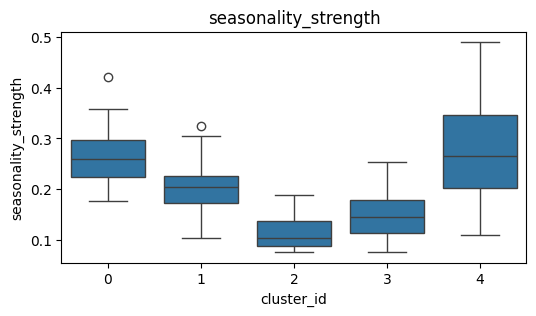

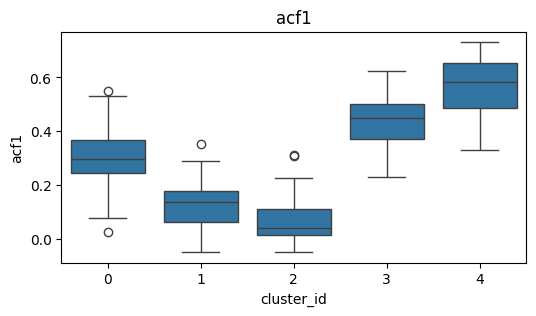

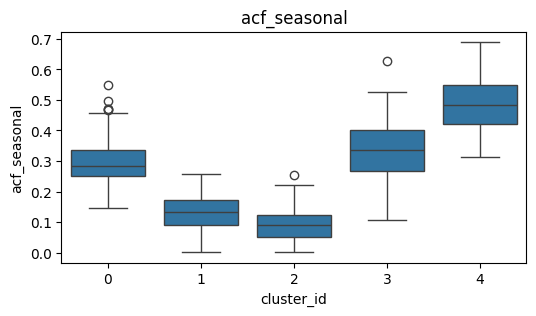

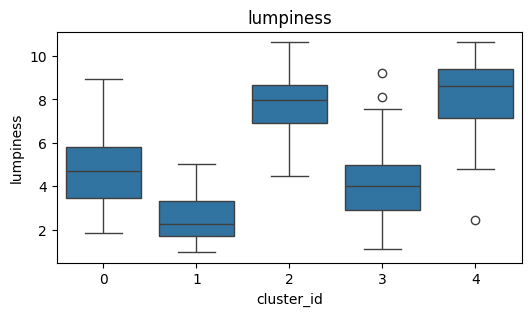

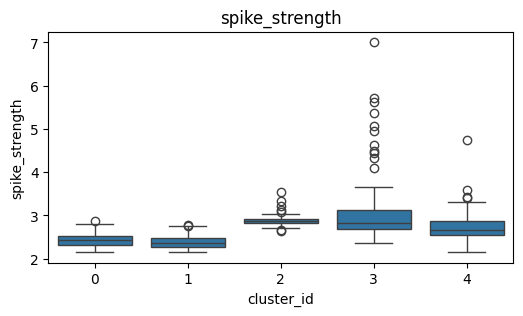

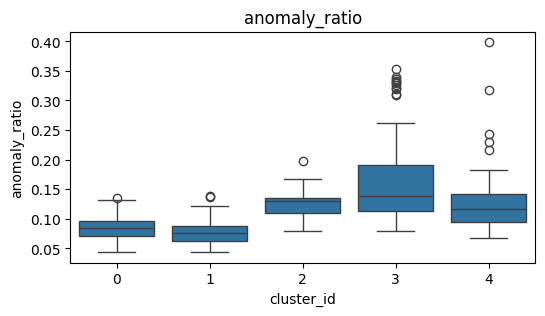

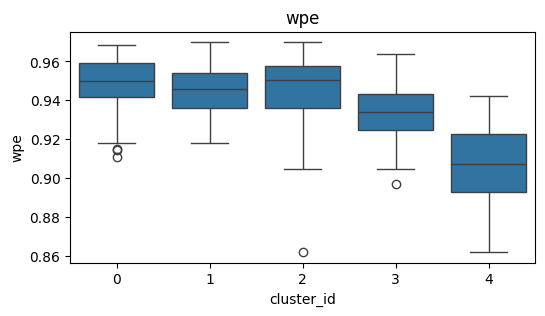

In [184]:
for col in X_explain.columns.drop("cluster_id"):
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=X_explain, x="cluster_id", y=col)
    plt.title(col)
    plt.show()

Các cluster thể hiện những regime hành vi khác nhau rõ rệt của time series, chủ yếu dọc theo trục structure (ACF/seasonality) và regime instability (lumpiness, spikes, anomalies).

Cluster 0 - Moderately structured & stable

Có seasonality và autocorrelation ở mức trung bình, lumpiness vừa phải, ít anomaly. Đây là nhóm series hành vi khá đều, dễ mô hình hóa.

Cluster 1 - Weak structure & very stable

Seasonality, ACF thấp; lumpiness và anomaly thấp nhất. Đây là nhóm series ổn định nhất, ít regime shift, ít shock.

Cluster 2 - Unstructured but highly unstable

Seasonality và ACF rất thấp, nhưng lumpiness và anomaly cao. Series không có pattern lặp rõ ràng, thay đổi regime mạnh.

Cluster 3 - Shock-driven with memory

ACF cao, spike_strength và anomaly_ratio cao nhất. Series có “memory” nhưng thường xuyên bị shock, regime có event-driven behavior.

Cluster 4 - Strong seasonal & highly lumpy

Seasonality và ACF cao nhất, lumpiness cao nhất. Series có chu kỳ rõ nhưng không ổn định theo thời gian (seasonal nhưng hay lệch pha/biên độ).

In [192]:
from scipy.stats import kruskal

records = []

for col in X_explain.columns.drop("cluster_id"):
    groups = [
        X_explain.loc[X_explain["cluster_id"] == cid, col]
        for cid in X_explain["cluster_id"].unique()
    ]
    stat, p = kruskal(*groups)
    records.append({
        "feature": col,
        "kruskal_stat": stat,
        "p_value": p
    })

anova_df = pd.DataFrame(records).sort_values("p_value")
anova_df

,feature,kruskal_stat,p_value
1,acf1,261.132519,2.599791e-55
2,acf_seasonal,258.786846,8.325419e-55
4,spike_strength,204.111337,4.907475e-43
3,lumpiness,203.853069,5.576938e-43
0,seasonality_strength,196.947770,1.702332e-41
5,anomaly_ratio,175.031524,8.697773e-37
6,wpe,108.789332,1.318756e-22


p-value của tất cả các feature đều rất nhỏ (<0.05), cho thấy khác biệt về giá trị của feature giuwax các cluster là có ý nghĩa thống kê.

In [193]:
from sklearn.feature_selection import mutual_info_classif

X_feat = X_explain.drop(columns="cluster_id")
y = X_explain["cluster_id"]

mi = mutual_info_classif(X_feat, y, random_state=42)

mi_df = pd.Series(mi, index=X_feat.columns).sort_values(ascending=False)
mi_df

acf1                    0.667539
acf_seasonal            0.647568
spike_strength          0.503331
lumpiness               0.467556
seasonality_strength    0.467208
anomaly_ratio           0.321530
wpe                     0.276898
dtype: float64

Mutual Information đo mức độ feature giúp dự đoán cluster label, không giả định tuyến tính.

acf1 và acf_seasonal có MI cao nhất cho thấy memory & seasonal structure là yếu tố giải thích cluster mạnh nhất.

spike_strength, lumpiness, seasonality_strength có MI trung bình cao, đóng vai trò phụ nhưng quan trọng.

anomaly_ratio và wpe có MI thấp hơn, mang thông tin bổ trợ, không phải trục phân tách chính.

MI cho thấy clustering chủ yếu dựa trên cấu trúc nội tại của series, hơn là chỉ mức độ bất thường.

In [194]:
def overlap_score(df, feature, label_col="cluster_id"):
    groups = df.groupby(label_col)[feature]
    medians = groups.median()
    iqr = groups.quantile(0.75) - groups.quantile(0.25)
    return medians.std() / iqr.mean()

scores = {
    col: overlap_score(X_explain, col)
    for col in X_explain.columns.drop("cluster_id")
}

pd.Series(scores).sort_values(ascending=False)

acf1                    1.763833
acf_seasonal            1.590375
lumpiness               1.354665
spike_strength          0.929765
seasonality_strength    0.921212
wpe                     0.864628
anomaly_ratio           0.693397
dtype: float64

Overlap score đánh giá mức độ tách biệt thực tế: median giữa cluster cách xa bao nhiêu so với độ phân tán trong cluster.

acf1 và acf_seasonal có overlap score cao nhất, boxplot giữa cluster ít chồng lấn, rất dễ phân biệt.

lumpiness và spike_strength cũng phân tách khá tốt.

anomaly_ratio và wpe có overlap thấp, nhiều overlap giữa cluster, khó dùng làm feature phân biệt chính.

Điều này giải thích vì sao một số feature có p-value nhỏ nhưng vẫn khó “nhìn thấy” khác biệt trên boxplot.

## 7. Refine & Tuning

In [245]:
dropped = ["wpe"]
kept_cols = [c for c in X_nonC_corr.columns if c not in dropped]
X_drop = X_nonC_corr[kept_cols]
scaler = StandardScaler()
X_nonC_scaled = scaler.fit_transform(X_drop)

In [246]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver="full")  # deterministic, stable
X_pca = pca.fit_transform(X_nonC_scaled)

explained_var = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))]
)
explained_var

cum_var = explained_var.cumsum()

TARGET_VAR = 0.95 
n_pc = int(np.searchsorted(cum_var.values, TARGET_VAR) + 1)

print(f"Keeping {n_pc} PCs: {cum_var.iloc[n_pc-1]:.2%} variance")

loadings = pd.DataFrame(
    pca.components_[:n_pc].T,
    index=X_drop.columns,
    columns=[f"PC{i+1}" for i in range(n_pc)],
)
loadings

PC_COLUMNS = [f"PC{i+1}" for i in range(n_pc)]

embedding_nonC = pd.DataFrame(
    X_pca[:, :n_pc],
    index=X_nonC.index,
    columns=PC_COLUMNS,
)

Keeping 4 PCs: 95.65% variance


In [247]:
# method 2
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.015,  # ~1.5%
    random_state=42
)

outlier_labels = iso.fit_predict(embedding_nonC)
# -1 = outlier, 1 = inlier

outlier_mask = outlier_labels == -1

len(outlier_mask[outlier_mask == True])

6

In [248]:
# Inliers only
embedding_inliers = embedding_nonC.loc[~outlier_mask].copy()

In [249]:
records = []

for k in range(2, 7):
    rec = evaluate_k_feature_clustering(
        embedding_inliers,   # PCA embedding (đã drop outliers)
        k,
    )
    records.append(rec)

k_eval_df = pd.DataFrame(records)

df = k_eval_df.copy()

df["sil_norm"] = (df["silhouette"] - df["silhouette"].min()) / (
    df["silhouette"].max() - df["silhouette"].min()
)

df["disp_norm"] = (df["mean_dispersion"] - df["mean_dispersion"].min()) / (
    df["mean_dispersion"].max() - df["mean_dispersion"].min()
)

df["size_norm"] = (df["size_imbalance"] - df["size_imbalance"].min()) / (
    df["size_imbalance"].max() - df["size_imbalance"].min()
)

# Composite score
df["score"] = (
    df["sil_norm"]
    - 0.6 * df["disp_norm"]
    - 0.4 * df["size_norm"]
)

df.sort_values("score", ascending=False)

,k,silhouette,mean_dispersion,size_imbalance,sil_norm,disp_norm,size_norm,score
4,6,0.346504,0.589925,0.668410,1.000000,0.000000,0.633104,0.746758
0,2,0.342417,0.870158,0.428305,0.901055,1.000000,0.000000,0.301055
2,4,0.343007,0.693643,0.807556,0.915339,0.370113,1.000000,0.293271
3,5,0.305199,0.636627,0.603053,0.000000,0.166655,0.460773,-0.284302
1,3,0.320382,0.791320,0.667380,0.367570,0.718669,0.630387,-0.315786


In [251]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(embedding_inliers)

l3_df = embedding_inliers.copy()
l3_df["cluster_id"] = cluster_labels

cluster_sizes = l3_df["cluster_id"].value_counts().sort_index()
cluster_sizes

cluster_id
0     81
1    114
2     14
3     29
4     32
5     80
Name: count, dtype: int64

In [252]:
X_explain = X_drop.loc[embedding_inliers.index].copy()
X_explain["cluster_id"] = cluster_labels

cluster_stats = (
    X_explain
    .groupby("cluster_id")
    .agg(["mean", "median"])
)
cluster_stats

seasonality_strength                acf1           acf_seasonal  \
                           mean    median      mean    median         mean   
cluster_id                                                                   
0                      0.279179  0.273659  0.263073  0.257568     0.284715   
1                      0.195406  0.196553  0.126538  0.129265     0.127190   
2                      0.133887  0.119125  0.477499  0.445629     0.450162   
3                      0.112178  0.101508  0.066559  0.039400     0.088204   
4                      0.293379  0.280961  0.573080  0.571968     0.500669   
5                      0.163150  0.168816  0.425511  0.430264     0.318297   

                     lumpiness           spike_strength            \
              median      mean    median           mean    median   
cluster_id                                                          
0           0.273848  4.371813  4.295040       2.392463  2.369377   
1           0.130726  2.547760  2.357199       2.384051  2.365341   
2           0.431530  3.654594  3.013306       4.990266  4.851071   
3           0.086223  7.904259  8.023435       2.905698  2.876411   
4           0.499545  8.406287  8.723324       2.742325  2.593132   
5           0.322781  4.568585  4.351396       2.742859  2.722158   

           anomaly_ratio            
                    mean    median  
cluster_id                          
0               0.079183  0.079735  
1               0.077900  0.076035  
2               0.324328  0.327863  
3               0.124903  0.129272  
4               0.118710  0.106160  
5               0.124892  0.119559

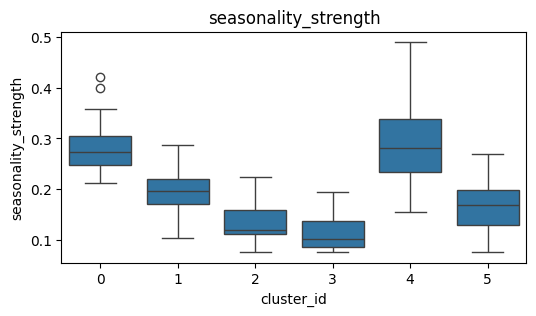

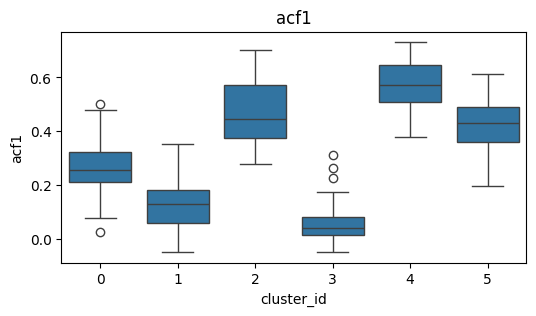

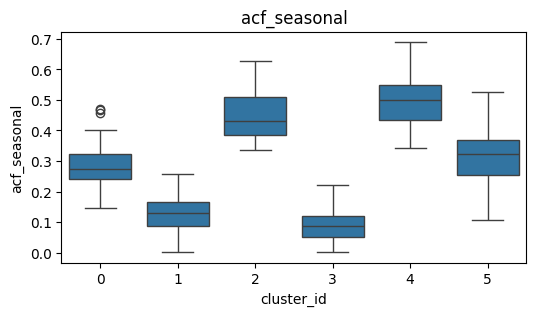

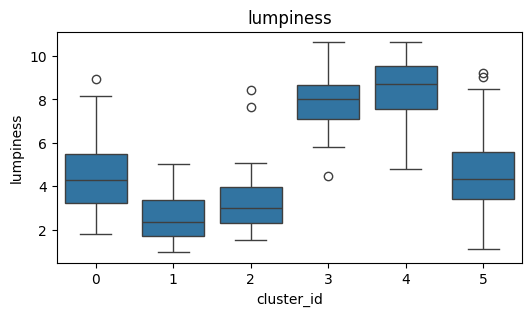

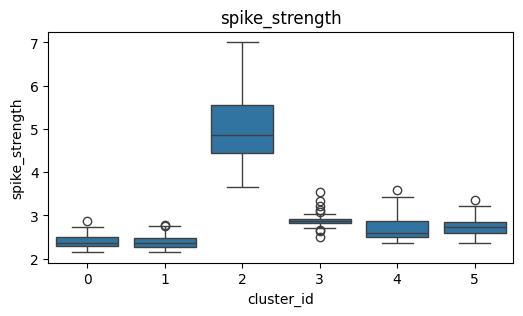

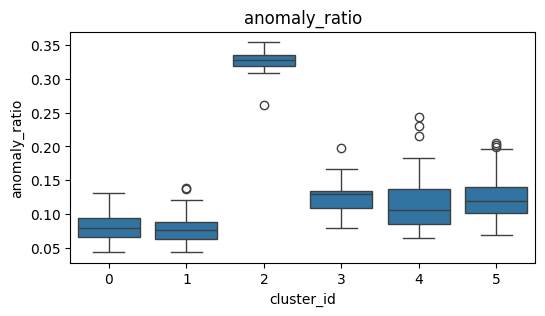

In [253]:
for col in X_explain.columns.drop("cluster_id"):
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=X_explain, x="cluster_id", y=col)
    plt.title(col)
    plt.show()

In [254]:
from scipy.stats import kruskal

records = []

for col in X_explain.columns.drop("cluster_id"):
    groups = [
        X_explain.loc[X_explain["cluster_id"] == cid, col]
        for cid in X_explain["cluster_id"].unique()
    ]
    stat, p = kruskal(*groups)
    records.append({
        "feature": col,
        "kruskal_stat": stat,
        "p_value": p
    })

anova_df = pd.DataFrame(records).sort_values("p_value")
anova_df

,feature,kruskal_stat,p_value
2,acf_seasonal,269.992481,2.808929e-56
1,acf1,265.990860,2.031545e-55
0,seasonality_strength,227.118313,4.434103e-47
4,spike_strength,213.205826,4.236986e-44
3,lumpiness,194.968187,3.385524e-40
5,anomaly_ratio,179.850459,5.759424e-37


In [255]:
from sklearn.feature_selection import mutual_info_classif

X_feat = X_explain.drop(columns="cluster_id")
y = X_explain["cluster_id"]

mi = mutual_info_classif(X_feat, y, random_state=42)

mi_df = pd.Series(mi, index=X_feat.columns).sort_values(ascending=False)
mi_df

acf_seasonal            0.668690
acf1                    0.658416
spike_strength          0.581086
seasonality_strength    0.528232
lumpiness               0.443314
anomaly_ratio           0.401008
dtype: float64

In [256]:
def overlap_score(df, feature, label_col="cluster_id"):
    groups = df.groupby(label_col)[feature]
    medians = groups.median()
    iqr = groups.quantile(0.75) - groups.quantile(0.25)
    return medians.std() / iqr.mean()

scores = {
    col: overlap_score(X_explain, col)
    for col in X_explain.columns.drop("cluster_id")
}

pd.Series(scores).sort_values(ascending=False)

anomaly_ratio           3.059873
spike_strength          2.553603
acf_seasonal            1.676944
acf1                    1.615353
lumpiness               1.398331
seasonality_strength    1.193588
dtype: float64

Ở baseline, clustering có silhouette ≈ 0.27 và mean dispersion ≈ 0.70, cho thấy các cụm còn loãng và chưa khai thác tốt sự khác biệt hành vi. Ta thực hiện thử nghiệm loại bỏ 1 số feature có khả năng gây nhiễu là `wpe` & `anomaly_ratio` (contribute vào việc định hình clustering thấp, overlap gía trị giữa cluster cao).

Khi loại bỏ `wpe`, silhouette tăng lên ≈ 0.35, dispersion giảm xuống ≈ 0.59 và score tổng hợp tăng gần gấp đôi, chứng tỏ inner variance giảm đáng kể trong khi outer variance vẫn được giữ rõ ràng. Việc bỏ `wpe` giúp loại nhiễu do feature complexity liên tục, làm nổi bật các trục hành vi chính gồm **structure/memory** (acf, seasonality), **regime instability** (lumpiness) và **shock/anomaly** (spike_strength, anomaly_ratio). Quan sát trực quan nhất khi `anomaly_ratio` không còn bị overlap nhiều giữa các cluster như baseline.


Ngược lại, khi loại bỏ `anomaly_ratio`, clustering bị collapse về 2 cụm do mất feature phá đối xứng, khiến không gian bị chi phối gần như hoàn toàn bởi ACF. Vì vậy, giữ `anomaly_ratio` để bảo toàn trục shock và chỉ loại `wpe` nhằm đạt được clustering đa chiều  và dễ giải thích hơn. 

# Phương pháp phân cụm khác

## DTW

### On cluster 1

`struct_cluster_1` (từ bước phân cụm dựa trên feature) bao gồm các chuỗi thời gian có cấu trúc rõ ràng (trend/ACF cao, entropy thấp), nhưng spike, lumpiness & instability cao. Ta nghi ngờ các chuỗi có cùng mức độ structure, nhưng structure đó bị phá/điều khiển bởi event/regime khác nhau theo thời gian -> vẫn tồn tại mức độ không đồng nhất lớn bên trong cụm.

Dynamic Time Warping (DTW) được áp dụng cục bộ trên cụm này nhằm:

Phát hiện các nhóm regime khác nhau theo thời gian (ví dụ: kích hoạt sớm vs kích hoạt muộn)

Tách các chuỗi có đặc tính cấu trúc tương tự nhau nhưng khác nhau về thời điểm vận hành

DTW đóng vai trò như một lớp phân tích bổ sung để làm rõ regime trong các cụm có cấu trúc.

In [ ]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sktime.clustering.k_medoids import TimeSeriesKMedoids

In [386]:
# Cluster id 1 only
cluster_id = 1
cluster_series_ids = l3_df.index[l3_df["cluster_id"] == cluster_id].tolist()

# Build fixed-length raw matrix (n_series, T), không dropna để tránh lệch length
X_raw = df[cluster_series_ids].to_numpy().T  # shape: (n_series, T)

# fill NaN theo trục thời gian: forward fill, backward fill
X_raw = pd.DataFrame(X_raw).ffill(axis=1).bfill(axis=1).to_numpy()
X_raw = np.nan_to_num(X_raw, nan=0.0)

# Scaling cho DTW shape-check (z-norm per series)
X_ts = X_raw[:, :, None]  # (n_series, T, 1)
X_ts = TimeSeriesScalerMeanVariance().fit_transform(X_ts)

In [396]:
# KMedoids + DTW 
dtw_kmed = TimeSeriesKMedoids(
    n_clusters=2,                 # cluster bé ~67
    metric="dtw",
    distance_params={"window": 0.015},  # Sakoe-Chiba window radius
    n_init=1,
    max_iter=10,
    verbose=True,
    random_state=42,
)

shape_labels = dtw_kmed.fit_predict(X_ts)

Iteration 0, inertia 56861.027691581825.
Iteration 1, inertia 92615.10969788342.
Iteration 2, inertia 90658.41889494793.


In [397]:
print("DTW-KMedoids cluster sizes:")
print(pd.Series(shape_labels).value_counts().sort_index())

# cluster_centers_ shape: (n_clusters, n_dims, T)
medoids = dtw_kmed.cluster_centers_
print("Medoids array shape:", medoids.shape)

DTW-KMedoids cluster sizes:
0    34
1    33
Name: count, dtype: int64
Medoids array shape: (2, 1000, 1)


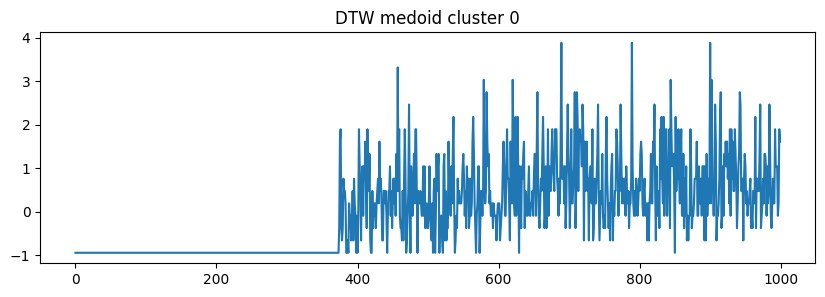

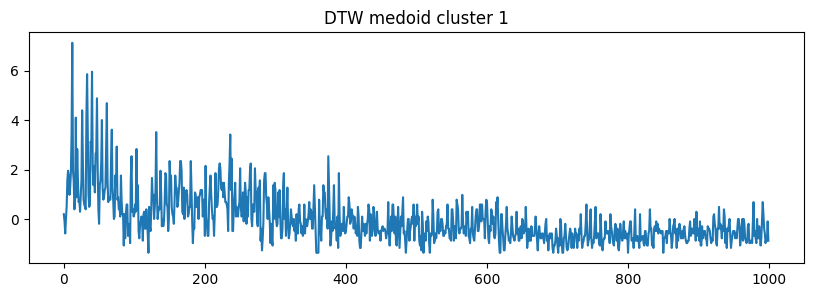

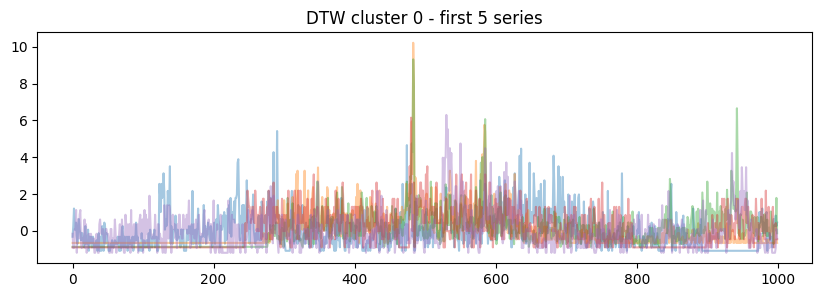

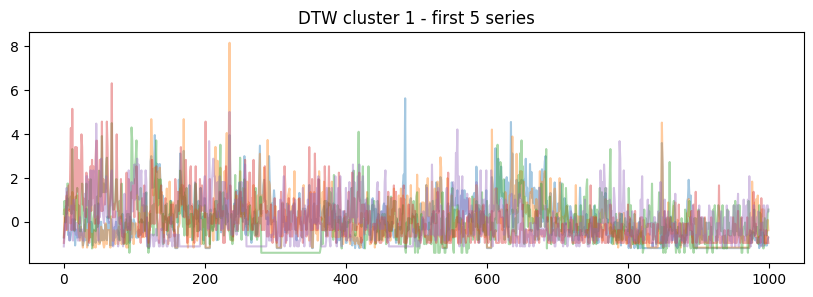

In [398]:
def plot_cluster_examples(X_ts, labels, cluster_id, n_examples=5):
    idx = np.where(labels == cluster_id)[0]
    plt.figure(figsize=(10, 3))
    for i in idx[:n_examples]:
        plt.plot(X_ts[i, :, 0], alpha=0.4)
    plt.title(f"DTW cluster {cluster_id} - first {n_examples} series")
    plt.show()

# Plot medoids
for c in [0, 1]:
    plt.figure(figsize=(10, 3))
    plt.plot(medoids[c, :, 0])
    plt.title(f"DTW medoid cluster {c}")
    plt.show()

# Plot 5 series trong mỗi cluster
plot_cluster_examples(X_ts, shape_labels, cluster_id=0)
plot_cluster_examples(X_ts, shape_labels, cluster_id=1)

In [399]:
feature_cols = ["trend_strength", "acf1", "acf_seasonal", "spectral_entropy"]
# Map DTW labels về feature dataframe
dtw_df = l3_df.loc[cluster_series_ids].copy()
dtw_df["dtw_cluster"] = shape_labels

# Mean profile
display(
    dtw_df.groupby("dtw_cluster")[feature_cols].mean()
)

# Std (dispersion)
display(
    dtw_df.groupby("dtw_cluster")[feature_cols].std()
)

,trend_strength,acf1,acf_seasonal,spectral_entropy
dtw_cluster,,,,
0,1.766273,1.509107,1.716549,-1.863422
1,1.295951,1.365455,1.363343,-1.279495


,trend_strength,acf1,acf_seasonal,spectral_entropy
dtw_cluster,,,,
0,0.847802,0.584193,0.670667,1.151721
1,0.433841,0.467226,0.569688,0.744824


In [400]:
def first_change_point(ts, threshold=0.3):
    diff = np.abs(np.diff(ts))
    idx = np.where(diff > threshold * diff.max())[0]
    return idx[0] if len(idx) > 0 else None

dtw_df["cp"] = [
    first_change_point(X_ts[i, :, 0])
    for i in range(len(X_ts))
]

display(
    dtw_df.groupby("dtw_cluster")["cp"].describe()
)

,count,mean,std,min,25%,50%,75%,max
dtw_cluster,,,,,,,,
0,34.0,195.323529,217.497575,2.0,13.0,93.5,342.25,734.0
1,33.0,22.424242,46.223662,0.0,3.0,4.0,10.00,201.0


In [401]:
def horizon_variance(ts, h=30):
    return np.var(ts[-h:])

dtw_df["tail_var"] = [
    horizon_variance(X_ts[i, :, 0])
    for i in range(len(X_ts))
]

display(
    dtw_df.groupby("dtw_cluster")["tail_var"].describe()
)

,count,mean,std,min,25%,50%,75%,max
dtw_cluster,,,,,,,,
0,34.0,0.783525,0.876307,1.232595e-32,0.397951,0.522424,0.898003,4.813860
1,33.0,0.326038,0.200977,4.930381e-32,0.161136,0.297569,0.519561,0.692286


DTW-KMedoids chia `struct_cluster_1` thành các nhóm con với khác biệt regime rất rõ ràng và có ý nghĩa:

* Khác biệt lớn về thời điểm regime:

Một nhóm có hoạt động mạnh từ sớm và giảm dần theo thời gian

Một nhóm khác có giai đoạn yên lặng dài trước khi bắt đầu hoạt động

Điều này được xác nhận thông qua sự khác biệt lớn trong thống kê first change-point

* Khác biệt về khả năng dự báo:

Nhóm kích hoạt muộn có độ bất định cao hơn trong tương lai

Nhóm kích hoạt sớm có hành vi ổn định hơn ở horizon dự báo

* Độ đồng nhất nội cụm được cải thiện:

Các cụm con theo DTW có độ phân tán (std) của các feature cấu trúc thấp hơn

Các chuỗi trong mỗi nhóm con nhất quán hơn so với cụm feature ban đầu

**Kết luận:**
DTW giúp phát hiện một chiều regime theo thời gian mà phân cụm theo feature không thể hiện được, và chiều này ảnh hưởng trực tiếp đến chiến lược mô hình hóa và xử lý độ bất định.

## GMM cluster compare with KMeans

In [31]:
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

In [32]:
def within_cluster_dispersion(labels, X_df):
    """Mean of (mean std across features) inside each cluster"""
    labels = np.asarray(labels)
    disp = []
    for cid in np.unique(labels):
        cluster_data = X_df.iloc[labels == cid]
        # if cluster too small -> std NaN
        if cluster_data.shape[0] < 2:
            continue
        disp.append(cluster_data.std().mean())
    return float(np.mean(disp)) if len(disp) > 0 else np.nan


def summarize_clustering(name, X, X_df, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).value_counts().sort_index()
    size_imbalance = sizes.std() / sizes.mean()

    sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan
    disp = within_cluster_dispersion(labels, X_df)

    print(f"=== {name} ===")
    print(f"n_clusters: {len(np.unique(labels))}")
    print("Cluster sizes:\n", sizes.to_string())
    print(f"Silhouette: {sil:.3f}")
    print(f"Dispersion: {disp:.3f}")
    print(f"Size imbalance (std/mean): {size_imbalance:.3f}")
    print()
    
    return {
        "method": name,
        "n_clusters": len(np.unique(labels)),
        "silhouette": sil,
        "dispersion": disp,
        "size_imbalance": size_imbalance,
    }

In [37]:
k = 3

gmm3 = GaussianMixture(
    n_components=k,
    covariance_type="diag",
    random_state=42,
    n_init=5,
    reg_covar=1e-6,
)
labels_gmm3 = gmm3.fit_predict(X_cluster)

_ = summarize_clustering("GMM (k=3, full cov)", X_cluster, X_cluster_df, labels_gmm3)

=== GMM (k=3, full cov) ===
n_clusters: 3
Cluster sizes:
 0    126
1     92
2    138
Silhouette: 0.415
Dispersion: 0.495
Size imbalance (std/mean): 0.201



In [38]:
ari = adjusted_rand_score(labels, labels_gmm3)
nmi = normalized_mutual_info_score(labels, labels_gmm3)

print(f"ARI (KMeans vs GMM k=3): {ari:.3f}")
print(f"NMI (KMeans vs GMM k=3): {nmi:.3f}")

ARI (KMeans vs GMM k=3): 0.637
NMI (KMeans vs GMM k=3): 0.667


In [39]:
records = []

for k in range(2, 12):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=42,
        n_init=3,
        reg_covar=1e-6,
    )
    gmm.fit(X_cluster)

    labels = gmm.predict(X_cluster)

    rec = summarize_clustering(f"GMM (k={k})", X_cluster, X_cluster_df, labels)
    rec["k"] = k
    rec["bic"] = gmm.bic(X_cluster)
    rec["aic"] = gmm.aic(X_cluster)
    records.append(rec)

gmm_eval_df = pd.DataFrame(records).sort_values("bic")
gmm_eval_df

=== GMM (k=2) ===
n_clusters: 2
Cluster sizes:
 0    158
1    198
Silhouette: 0.502
Dispersion: 0.628
Size imbalance (std/mean): 0.159

=== GMM (k=3) ===
n_clusters: 3
Cluster sizes:
 0    126
1     92
2    138
Silhouette: 0.415
Dispersion: 0.495
Size imbalance (std/mean): 0.201

=== GMM (k=4) ===
n_clusters: 4
Cluster sizes:
 0    116
1     76
2    128
3     36
Silhouette: 0.384
Dispersion: 0.458
Size imbalance (std/mean): 0.469

=== GMM (k=5) ===
n_clusters: 5
Cluster sizes:
 0    117
1     71
2     62
3     86
4     20
Silhouette: 0.355
Dispersion: 0.421
Size imbalance (std/mean): 0.498

=== GMM (k=6) ===
n_clusters: 6
Cluster sizes:
 0     29
1    116
2     53
3     62
4     81
5     15
Silhouette: 0.339
Dispersion: 0.391
Size imbalance (std/mean): 0.613

=== GMM (k=7) ===
n_clusters: 7
Cluster sizes:
 0    26
1    78
2    52
3    16
4    44
5    88
6    52
Silhouette: 0.286
Dispersion: 0.369
Size imbalance (std/mean): 0.508

=== GMM (k=8) ===
n_clusters: 8
Cluster sizes:
 0    49


,method,n_clusters,silhouette,dispersion,size_imbalance,k,bic,aic
6,GMM (k=8),8,0.273001,0.336471,0.440521,8,2123.003222,1847.883140
9,GMM (k=11),11,0.297159,0.292624,0.542497,11,2126.167013,1746.423801
7,GMM (k=9),9,0.288855,0.341221,0.618234,9,2131.325444,1821.330986
8,GMM (k=10),10,0.272723,0.315265,0.507729,10,2142.994747,1798.125912
4,GMM (k=6),6,0.338588,0.390933,0.612952,6,2150.015099,1944.643771
5,GMM (k=7),7,0.285629,0.368935,0.507622,7,2153.705745,1913.460040
3,GMM (k=5),5,0.355227,0.420914,0.497695,5,2201.439101,2030.942148
2,GMM (k=4),4,0.384125,0.457783,0.469048,4,2367.810287,2232.187712
1,GMM (k=3),3,0.415458,0.495238,0.201073,3,2554.412841,2453.664642
0,GMM (k=2),2,0.502370,0.627752,0.158900,2,3049.546177,2983.672355


In [40]:
best_row = gmm_eval_df.sort_values("bic").iloc[0]
best_k = int(best_row["k"])

print("Best k by BIC =", best_k)
best_row

Best k by BIC = 8


method              GMM (k=8)
n_clusters                  8
silhouette           0.273001
dispersion           0.336471
size_imbalance       0.440521
k                           8
bic               2123.003222
aic                1847.88314
Name: 6, dtype: object

In [41]:
gmm_best = GaussianMixture(
    n_components=best_k,
    covariance_type="diag",
    random_state=42,
    n_init=5,
    reg_covar=1e-6,
)
labels_gmm_best = gmm_best.fit_predict(X_cluster)

proba_best = gmm_best.predict_proba(X_cluster)  # shape (n_samples, best_k)
max_proba = proba_best.max(axis=1)              # confidence score
entropy = -(proba_best * np.log(proba_best + 1e-12)).sum(axis=1)  # uncertainty

_ = summarize_clustering(f"GMM Best (k={best_k}, BIC)", X_cluster, X_cluster_df, labels_gmm_best)

print("Probability matrix shape:", proba_best.shape)
print("Confidence (max prob) summary:")
print(pd.Series(max_proba).describe())

=== GMM Best (k=8, BIC) ===
n_clusters: 8
Cluster sizes:
 0    69
1    49
2    47
3    29
4    15
5    29
6    44
7    74
Silhouette: 0.278
Dispersion: 0.340
Size imbalance (std/mean): 0.453

Probability matrix shape: (356, 8)
Confidence (max prob) summary:
count    356.000000
mean       0.915134
std        0.136244
min        0.463855
25%        0.899583
50%        0.987971
75%        0.998609
max        1.000000
dtype: float64


In [43]:
ari_best = adjusted_rand_score(labels, labels_gmm_best)
nmi_best = normalized_mutual_info_score(labels, labels_gmm_best)

print(f"ARI (KMeans k=3 vs GMM best_k={best_k}): {ari_best:.3f}")
print(f"NMI (KMeans k=3 vs GMM best_k={best_k}): {nmi_best:.3f}")

ARI (KMeans k=3 vs GMM best_k=8): 0.659
NMI (KMeans k=3 vs GMM best_k=8): 0.780


In [44]:
cols_show = [
    "trend_strength", "acf1", "acf_seasonal", "spectral_entropy",
    "stability", "lumpiness", "spike_strength", "anomaly_ratio",
    "zero_ratio", "adi", "cv2"
]
cols_show = [c for c in cols_show if c in X_cluster_df.columns]

gmm_prof = X_cluster_df.copy()
gmm_prof["cluster"] = labels_gmm_best

print("GMM cluster mean profile:")
display(gmm_prof.groupby("cluster")[cols_show].mean())

print("GMM cluster std profile:")
display(gmm_prof.groupby("cluster")[cols_show].std())

GMM cluster mean profile:


,trend_strength,acf1,acf_seasonal,spectral_entropy
cluster,,,,
0,-0.753841,-0.769556,-0.858683,0.781076
1,0.972306,0.988514,0.800083,-0.609404
2,0.325151,0.553476,0.065213,0.068257
3,1.419610,1.428871,1.536897,-1.459204
4,2.342948,1.827821,2.451063,-3.085747
5,0.026820,0.000851,0.472297,-0.311686
6,-1.243341,-1.388530,-1.314895,1.052158
7,-0.449915,-0.393719,-0.272934,0.325750


GMM cluster std profile:


,trend_strength,acf1,acf_seasonal,spectral_entropy
cluster,,,,
0,0.251332,0.306281,0.247768,0.155298
1,0.281379,0.396112,0.282003,0.308760
2,0.209963,0.353501,0.249337,0.195331
3,0.282007,0.414345,0.206289,0.375644
4,1.084297,0.680822,0.558110,0.892691
5,0.231960,0.239003,0.212912,0.371625
6,0.219731,0.244835,0.242240,0.090732
7,0.356912,0.407130,0.302745,0.240797


GMM(diag) cho phép tách nhiều regime nhỏ và làm cluster đồng nhất hơn (dispersion giảm mạnh), nhưng đánh đổi bằng việc nhiều cụm hơn và silhouette thấp hơn. Có thể sử dụng thay thế KMean, hoặc làm clustering stage 2 (giống cách demo dùng DTW). Cách chọn k theo BIC có cơ sở lý thuyết tốt hơn.

# Phương pháp giảm chiều khác

## UMAP

In [50]:
import umap

/opt/miniconda3/envs/tspre/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
umap_model = umap.UMAP(
    n_components=2,        
    n_neighbors=30,
    min_dist=0.05,
    metric="euclidean",    # vì đã scale feature
    random_state=42,
)

X_umap_2d = umap_model.fit_transform(X_nonC_scaled)
print("UMAP embedding shape:", X_umap_2d.shape)

/opt/miniconda3/envs/tspre/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (356, 2)


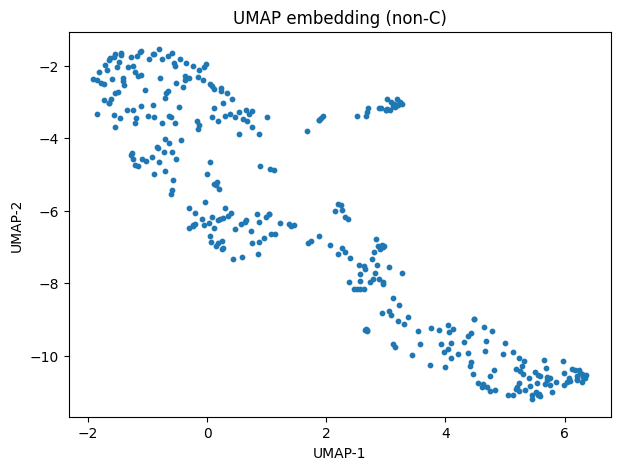

In [52]:
plt.figure(figsize=(7,5))
plt.scatter(X_umap_2d[:,0], X_umap_2d[:,1], s=10)
plt.title("UMAP embedding (non-C)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [53]:
k = 3
kmean_umap = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_umap = kmean_umap.fit_predict(X_umap_2d)

sil_umap = silhouette_score(X_umap_2d, labels_umap)

print("Silhouette (KMeans on UMAP-2D):", round(sil_umap, 3))
print("Cluster sizes:\n", pd.Series(labels_umap).value_counts().sort_index())

Silhouette (KMeans on UMAP-2D): 0.547
Cluster sizes:
 0     97
1    106
2    153
Name: count, dtype: int64


In [54]:
umap_df = nonC_df.loc[X_nonC.index].copy()
umap_df["umap_cluster"] = labels_umap

cols_show = [
    "trend_strength","seasonality_strength","acf1","acf_seasonal",
    "stability","lumpiness","spike_strength","anomaly_ratio",
    "spectral_entropy","wpe"
]
cols_show = [c for c in cols_show if c in umap_df.columns]

print("UMAP-cluster mean profile:")
display(umap_df.groupby("umap_cluster")[cols_show].mean())

print("UMAP-cluster std profile:")
display(umap_df.groupby("umap_cluster")[cols_show].std())

UMAP-cluster mean profile:


,trend_strength,seasonality_strength,acf1,acf_seasonal,stability,lumpiness,spike_strength,anomaly_ratio,spectral_entropy,wpe
umap_cluster,,,,,,,,,,
0,0.308918,0.239756,0.313702,0.269216,3.567954,123.855257,1.257472e+01,0.110289,0.848097,0.942180
1,0.502067,0.282984,0.500287,0.431925,47.490084,101240.701086,2.981664e+07,0.174698,0.759356,0.927932
2,0.155213,0.210910,0.110767,0.128616,2.540715,1179.975408,1.127708e+01,0.089327,0.900571,0.945082


UMAP-cluster std profile:


,trend_strength,seasonality_strength,acf1,acf_seasonal,stability,lumpiness,spike_strength,anomaly_ratio,spectral_entropy,wpe
umap_cluster,,,,,,,,,,
0,0.069908,0.091456,0.086044,0.058276,1.976066,214.425049,3.988480e+00,0.042217,0.022528,0.016075
1,0.134591,0.164089,0.115052,0.116852,194.614981,986119.734306,2.112933e+08,0.124990,0.077463,0.025936
2,0.066547,0.069862,0.079977,0.067764,4.261560,4829.766560,3.893633e+00,0.030941,0.022434,0.016540


In [55]:
umap_embed_df = pd.DataFrame(X_umap_2d, index=X_nonC.index, columns=["UMAP1", "UMAP2"])

corrs = []
for col in PCA_FEATURES:
    corr1 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP1"].values)[0,1]
    corr2 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP2"].values)[0,1]
    corrs.append({
        "feature": col,
        "corr_umap1": corr1,
        "corr_umap2": corr2,
        "max_abs_corr": max(abs(corr1), abs(corr2)),
    })

umap_feature_corr = pd.DataFrame(corrs).set_index("feature").sort_values("max_abs_corr", ascending=False)
umap_feature_corr

,corr_umap1,corr_umap2,max_abs_corr
feature,,,
acf1,0.762905,-0.909133,0.909133
acf_seasonal,0.723888,-0.885526,0.885526
trend_strength,0.742710,-0.876866,0.876866
spectral_entropy,-0.732339,0.826260,0.826260
stability,0.714650,-0.699410,0.714650
anomaly_ratio,0.635814,-0.466937,0.635814
lumpiness,0.578332,-0.466493,0.578332
wpe,-0.382638,0.366852,0.382638
spike_strength,0.352417,-0.261475,0.352417


In [56]:
umap_model_10d = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.05,
    metric="euclidean",
    random_state=42,
)

X_umap_10d = umap_model_10d.fit_transform(X_nonC_scaled)

k = 3
kmean_umap10 = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_umap10 = kmean_umap10.fit_predict(X_umap_10d)

sil_umap10 = silhouette_score(X_umap_10d, labels_umap10)
print("Silhouette (KMeans on UMAP-10D):", round(sil_umap10, 3))
print("Cluster sizes:\n", pd.Series(labels_umap10).value_counts().sort_index())

/opt/miniconda3/envs/tspre/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette (KMeans on UMAP-10D): 0.553
Cluster sizes:
 0    103
1    102
2    151
Name: count, dtype: int64


In [58]:
umap_df = nonC_df.loc[X_nonC.index].copy()
umap_df["umap_cluster"] = labels_umap10

cols_show = [
    "trend_strength","seasonality_strength","acf1","acf_seasonal",
    "stability","lumpiness","spike_strength","anomaly_ratio",
    "spectral_entropy","wpe"
]
cols_show = [c for c in cols_show if c in umap_df.columns]

print("UMAP-cluster 10 mean profile:")
display(umap_df.groupby("umap_cluster")[cols_show].mean())

print("UMAP-cluster 10 std profile:")
display(umap_df.groupby("umap_cluster")[cols_show].std())

UMAP-cluster 10 mean profile:


,trend_strength,seasonality_strength,acf1,acf_seasonal,stability,lumpiness,spike_strength,anomaly_ratio,spectral_entropy,wpe
umap_cluster,,,,,,,,,,
0,0.307104,0.241793,0.314626,0.265700,3.989629,194.274401,1.248065e+01,0.108650,0.849760,0.941947
1,0.511029,0.283690,0.505355,0.441143,48.749404,105132.882436,3.098591e+07,0.178010,0.754761,0.927706
2,0.153477,0.209806,0.108968,0.127236,2.552310,1195.365832,1.130678e+01,0.089636,0.900885,0.945054


UMAP-cluster 10 std profile:


,trend_strength,seasonality_strength,acf1,acf_seasonal,stability,lumpiness,spike_strength,anomaly_ratio,spectral_entropy,wpe
umap_cluster,,,,,,,,,,
0,0.068140,0.091772,0.087276,0.056601,3.027843,4.651552e+02,3.927292e+00,0.041655,0.022310,0.016022
1,0.129253,0.165967,0.112448,0.110204,198.324017,1.005256e+06,2.153518e+08,0.126265,0.075487,0.026223
2,0.065177,0.069450,0.078911,0.067080,4.288593,4.859982e+03,3.910762e+00,0.031015,0.022414,0.016647


In [60]:
umap_embed_df = pd.DataFrame(X_umap_10d, index=X_nonC.index, columns=["UMAP1", "UMAP2", "UMAP3", "UMAP4", "UMAP5", "UMAP6", "UMAP7", "UMAP8", "UMAP9", "UMAP10"])

corrs = []
for col in PCA_FEATURES:
    corr1 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP1"].values)[0,1]
    corr2 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP2"].values)[0,1]
    corr3 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP3"].values)[0,1]
    corr4 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP4"].values)[0,1]
    corr5 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP5"].values)[0,1]
    corr6 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP6"].values)[0,1]
    corr7 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP7"].values)[0,1]
    corr8 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP8"].values)[0,1]
    corr9 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP9"].values)[0,1]
    corr10 = np.corrcoef(X_nonC[col].values, umap_embed_df["UMAP10"].values)[0,1]
    corrs.append({
        "feature": col,
        "corr_umap1": corr1,
        "corr_umap2": corr2,
        "corr_umap3": corr3,
        "corr_umap4": corr4,
        "corr_umap5": corr5,
        "corr_umap6": corr6,
        "corr_umap7": corr7,
        "corr_umap8": corr8,
        "corr_umap9": corr9,
        "corr_umap10": corr10,
        "max_abs_corr": max(abs(corr1), abs(corr2), abs(corr3), abs(corr4), abs(corr5),abs(corr6),abs(corr7),abs(corr8),abs(corr9),abs(corr10)),
    })

umap_feature_corr = pd.DataFrame(corrs).set_index("feature").sort_values("max_abs_corr", ascending=False)
umap_feature_corr

,corr_umap1,corr_umap2,corr_umap3,corr_umap4,corr_umap5,corr_umap6,corr_umap7,corr_umap8,corr_umap9,corr_umap10,max_abs_corr
feature,,,,,,,,,,,
acf1,0.292474,0.899006,-0.914967,-0.903192,0.715054,-0.068296,0.872581,-0.849730,0.467149,-0.817580,0.914967
trend_strength,0.323529,0.885872,-0.870983,-0.869621,0.652098,-0.055527,0.855972,-0.843822,0.459941,-0.770507,0.885872
acf_seasonal,0.288781,0.874877,-0.867639,-0.855174,0.617020,-0.043873,0.843808,-0.856773,0.495601,-0.777060,0.874877
spectral_entropy,-0.392763,-0.847976,0.804004,0.809341,-0.538198,0.077063,-0.801082,0.851482,-0.379384,0.730877,0.851482
stability,0.478686,0.689888,-0.678707,-0.736729,0.250704,-0.565971,0.501442,-0.642076,-0.020825,-0.765116,0.765116
lumpiness,0.462633,0.446305,-0.443567,-0.516365,-0.013222,-0.731707,0.224381,-0.424828,-0.278590,-0.625773,0.731707
anomaly_ratio,0.578169,0.554243,-0.443157,-0.488076,0.202214,-0.249339,0.505385,-0.658567,-0.101158,-0.492857,0.658567
wpe,-0.380640,-0.434022,0.362904,0.386305,-0.439538,-0.062308,-0.467290,0.444928,-0.033081,0.267340,0.467290
seasonality_strength,-0.179812,0.205213,-0.244016,-0.194189,0.167035,0.224264,0.206456,-0.168479,0.450075,-0.139407,0.450075


UMAP được thử như một phương án giảm chiều thay thế PCA. Với dataset demo, UMAP (2D/10D) cho kết quả clustering tương đồng PCA vì feature space đã có một trục phân hoá chính (structured vs unstructured). UMAP vẫn hữu ích như một lựa chọn dự phòng khi feature space phi tuyến hoặc PCA không tách cụm rõ.

# Phương pháp extract feature khác

## TSFeatures

In [6]:
from tsfeatures import tsfeatures

In [44]:
def wide_to_long_tsfeatures(df_wide: pd.DataFrame) -> pd.DataFrame:
    """long df with columns [unique_id, ds, y]"""
    df_tmp = df_wide.copy()

    # Ensure datetime index
    df_tmp.index = pd.to_datetime(df_tmp.index)

    # If index has no name, set one
    if df_tmp.index.name is None:
        df_tmp.index.name = "ds"
    else:
        # rename index to ds for tsfeatures convention
        df_tmp.index.name = "ds"

    df_long = (
        df_tmp
        .stack()
        .reset_index()
        .rename(columns={0: "y", df_tmp.columns.name or "level_1": "unique_id"})
    )

    # after reset_index, columns are: ["ds", <series_id_col>, "y"]
    # figure out series id column name
    if "unique_id" not in df_long.columns:
        # fallback: second column is series_id
        df_long = df_long.rename(columns={df_long.columns[1]: "unique_id"})

    # enforce types
    df_long["ds"] = pd.to_datetime(df_long["ds"])
    df_long["y"] = df_long["y"].astype(float)

    return df_long


df_long = wide_to_long_tsfeatures(df)
df_long.head()

,ds,unique_id,y
0,2013-08-27,FOODS_1_001,0.0
1,2013-08-27,FOODS_1_002,0.0
2,2013-08-27,FOODS_1_003,1.0
3,2013-08-27,FOODS_1_004,4.0
4,2013-08-27,FOODS_1_005,1.0


In [11]:
from tsfeatures.tsfeatures import (
    acf_features,
    entropy,
    lumpiness,
    stability,
    flat_spots,
    unitroot_kpss,
    stl_features,
)

In [ ]:
FREQ = 7  

features_ts = tsfeatures(
    df_long,
    freq=FREQ,
    features=[
        acf_features,
        entropy,
        lumpiness,
        stability,
        flat_spots,
        unitroot_kpss,
        stl_features,
    ],
    threads=1,  
)

features_ts.head()

In [13]:
features_ts_df = features_ts.set_index("unique_id")
features_ts_df.head()
features_ts_df.columns.tolist()

['nperiods',
 'seasonal_period',
 'trend',
 'spike',
 'linearity',
 'curvature',
 'e_acf1',
 'e_acf10',
 'seasonal_strength',
 'peak',
 'trough',
 'unitroot_kpss',
 'flat_spots',
 'stability',
 'lumpiness',
 'entropy',
 'x_acf1',
 'x_acf10',
 'diff1_acf1',
 'diff1_acf10',
 'diff2_acf1',
 'diff2_acf10',
 'seas_acf1']

In [40]:
common_ids = features_df.index.intersection(features_ts_df.index)

comp_df = features_df.loc[common_ids].join(features_ts_df.loc[common_ids], how="inner", lsuffix="_manual",rsuffix="_tsf")

print("Joined shape:", comp_df.shape)

FEATURE_MAPPING = {
    "acf1": ("acf1", "x_acf1"),
    "acf_seasonal": ("acf_seasonal", "seas_acf1"),
    "seasonality_strength": ("seasonality_strength", "seasonal_strength"),
    "stability": ("stability_manual", "stability_tsf"),
    "lumpiness": ("lumpiness_manual", "lumpiness_tsf"),
}


valid_mapping = {
    m: t for m, t in FEATURE_MAPPING.items()
    if (m in features_df.columns) and (t in features_ts_df.columns)
}

print("Valid mapping:", valid_mapping)


Joined shape: (3049, 38)
Valid mapping: {}


In [41]:
records = []

for key, (mcol, tcol) in FEATURE_MAPPING.items():
    if (mcol not in comp_df.columns) or (tcol not in comp_df.columns):
        continue

    x = comp_df[mcol].values
    y = comp_df[tcol].values

    mask = np.isfinite(x) & np.isfinite(y)
    x2, y2 = x[mask], y[mask]

    corr = np.corrcoef(x2, y2)[0, 1] if len(x2) > 5 else np.nan

    records.append({
        "feature": key,
        "manual_col": mcol,
        "tsfeatures_col": tcol,
        "n": int(mask.sum()),
        "corr": float(corr),
        "mean_manual": float(np.mean(x2)) if len(x2) else np.nan,
        "mean_tsfeatures": float(np.mean(y2)) if len(y2) else np.nan,
        "std_manual": float(np.std(x2)) if len(x2) else np.nan,
        "std_tsfeatures": float(np.std(y2)) if len(y2) else np.nan,
    })

compare_stats = pd.DataFrame(records).sort_values("corr", ascending=False)
compare_stats

,feature,manual_col,tsfeatures_col,n,corr,mean_manual,mean_tsfeatures,std_manual,std_tsfeatures
0,acf1,acf1,x_acf1,3049,1.000000,0.177870,0.177870,0.168028,0.168028
1,acf_seasonal,acf_seasonal,seas_acf1,3049,1.000000,0.159573,0.159573,0.142930,0.142930
2,seasonality_strength,seasonality_strength,seasonal_strength,3049,0.930204,0.386781,0.222135,0.050334,0.058694
3,stability,stability_manual,stability_tsf,3049,0.178214,3.257786,0.264750,38.382212,0.125012
4,lumpiness,lumpiness_manual,lumpiness_tsf,3049,0.026945,4034.000823,1.758880,184276.019689,3.247837


Thay vì tự tính từng feature bằng nhiều package rời rạc (statsmodels / scipy / ordpy / antropy…), ta có thể dùng **Nixtla `tsfeatures`** để trích xuất một feature bank chuẩn hoá theo các nghiên cứu meta-learning forecasting (FFORMA/FFORMS).

### Vì sao dùng `tsfeatures`
- 1 hàm gọi ra nhiều feature quan trọng (ACF, entropy, STL-based, stability/lumpiness, …).
- Feature được định nghĩa theo một framework thống nhất, dễ maintain và dễ giải thích.
- Giảm “manual code” (ít bug hơn, ít dependency tự lắp ghép).

### Nhược điểm 
  - Không cover hết feature. Ví dụ ADI/CV² không có sẵn vẫn cần tính riêng. 
  - Một số feature có “tên giống” nhưng công thức khác (vd. `trend`, `entropy`) → không nên assume thay thế 1:1.
  - `freq` trong tsfeatures chủ yếu dùng để set seasonal period / windowing. Nếu seasonality không đồng nhất giữa các series thì feature STL-based có thể bị bias.


Khi map các feature “tương đương” giữa 2 cách tính, ta kiểm tra correlation thấy có 2 trường hợp. 1 là corr rất cao, tsfeatures thay thế được hoàn toàn cách tự tính. 2 là corr rất thấp, cho thấy khả năng cao định nghĩa/công thức/cách preprocess đang khác mặc dù feature trùng tên. Vì vậy, corr thấp không có nghĩa tsfeatures “sai”.

## MSTL

In [8]:
import time

def strength(component: np.ndarray, resid: np.ndarray):
    var_resid = np.nanvar(resid)
    var_total = np.nanvar(component + resid)
    if var_total <= 0:
        return 0.0
    return max(0.0, 1 - var_resid / var_total)

def mstl_seasonality_strength_auto(series: pd.Series, periods=(7, 30), robust=True):
    series = series.dropna().astype(float)

    if len(series) < 3 * max(periods):
        return 1, 0.0

    res = MSTL(series, periods=list(periods)).fit()

    resid = res.resid.to_numpy() if hasattr(res.resid, "to_numpy") else np.asarray(res.resid)

    best_p = 1
    best_strength = 0.0

    for p in periods:
        seasonal_comp = res.seasonal[f"seasonal_{p}"]
        seasonal_arr = seasonal_comp.to_numpy() if hasattr(seasonal_comp, "to_numpy") else np.asarray(seasonal_comp)

        s = strength(seasonal_arr, resid)
        if s > best_strength:
            best_strength = s
            best_p = p

    return int(best_p), float(best_strength)

def stl_seasonality_strength(series: pd.Series, period=7, robust=True):
    """STL strength for 1 fixed period."""
    series = series.dropna().astype(float)

    if len(series) < 3 * period:
        return 1, 0.0

    res = STL(series, period=period, robust=robust).fit()

    resid = res.resid.to_numpy() if hasattr(res.resid, "to_numpy") else np.asarray(res.resid)
    seasonal = res.seasonal.to_numpy() if hasattr(res.seasonal, "to_numpy") else np.asarray(res.seasonal)

    s = strength(seasonal, resid)
    return int(period), float(s)

# RUN RANDOM SAMPLE (400 series)
periods = (7, 30, 60, 90)     # MSTL candidate set
stl_period = 7               # STL fixed period (compare speed)
sample_n = 400
random_state = 42
df_daily = df.copy()

sample_cols = pd.Index(df_daily.columns).to_series().sample(
    n=min(sample_n, len(df_daily.columns)),
    random_state=random_state
).tolist()

# Benchmark MSTL
t0 = time.time()

mstl_best_periods = []
mstl_best_strengths = []

for sid in sample_cols:
    bp, bs = mstl_seasonality_strength_auto(df_daily[sid], periods=periods, robust=True)
    mstl_best_periods.append(bp)
    mstl_best_strengths.append(bs)

mstl_elapsed = time.time() - t0

mstl_best_periods = pd.Series(mstl_best_periods, index=sample_cols, name="mstl_best_period")
mstl_best_strengths = pd.Series(mstl_best_strengths, index=sample_cols, name="mstl_best_strength")

# Benchmark STL
t1 = time.time()

stl_periods = []
stl_strengths = []

for sid in sample_cols:
    p, s = stl_seasonality_strength(df_daily[sid], period=stl_period, robust=True)
    stl_periods.append(p)
    stl_strengths.append(s)

stl_elapsed = time.time() - t1

stl_periods = pd.Series(stl_periods, index=sample_cols, name="stl_period")
stl_strengths = pd.Series(stl_strengths, index=sample_cols, name="stl_strength")

# Report
print(f"Sample size: {len(sample_cols)} series (out of {df_daily.shape[1]})")

print("\n--- MSTL ---")
print(f"Total time: {mstl_elapsed:.2f} seconds")
print(f"Avg time/series: {mstl_elapsed/len(sample_cols):.4f} seconds")
print("Best period distribution:")
display(mstl_best_periods.value_counts())

print("\n--- STL ---")
print(f"Total time: {stl_elapsed:.2f} seconds")
print(f"Avg time/series: {stl_elapsed/len(sample_cols):.4f} seconds")
print(f"Fixed period used: {stl_period}")

print("\n--- Speed Ratio ---")
ratio = mstl_elapsed / stl_elapsed if stl_elapsed > 0 else np.nan
print(f"MSTL / STL time ratio ≈ {ratio:.2f}x")

# quick compare strength stats
compare_strength_df = pd.DataFrame({
    "mstl_best_strength": mstl_best_strengths,
    "stl_strength": stl_strengths
})

print("\nStrength summary:")
display(compare_strength_df.describe())

Sample size: 400 series (out of 3049)

--- MSTL ---
Total time: 104.78 seconds
Avg time/series: 0.2620 seconds
Best period distribution:


mstl_best_period
7     335
30     49
90     15
60      1
Name: count, dtype: int64


--- STL ---
Total time: 16.84 seconds
Avg time/series: 0.0421 seconds
Fixed period used: 7

--- Speed Ratio ---
MSTL / STL time ratio ≈ 6.22x

Strength summary:


,mstl_best_strength,stl_strength
count,400.000000,400.000000
mean,0.270088,0.146376
std,0.057496,0.170996
min,0.165125,0.000000
25%,0.233071,0.054600
50%,0.260472,0.110150
75%,0.289681,0.176752
max,0.710503,1.000000


Thử nghiệm chạy MSTL trên ~400 series (xấp xỉ nhóm non-Type C) để tự động so sánh nhiều chu kỳ mùa vụ (ví dụ: 7/30/60/90). Kết quả cho thấy MSTL có khả năng “bắt” seasonality hợp lý hơn STL cố định trong trường hợp các series không đồng nhất về chu kỳ (weekly vs monthly…), nhờ cơ chế chọn `best_period` theo strength.

Tuy nhiên, runtime của MSTL cao hơn STL đáng kể (≈ gấp 7 lần) do phải decomposition nhiều seasonal component thay vì chỉ 1 chu kỳ.

Do đó, giữ STL (fixed period) làm mặc định để đảm bảo tốc độ và scale. Chỉ bật MSTL khi:

* không chắc seasonality period đúng (data đa dạng hoặc unknown),
* cần phân tích sâu một subset (sample nhỏ / structured pool) để kiểm tra giả thuyết về seasonality.

**Note:** giữ best period làm 1 feature nếu sử dụng MSTL